In [ ]:
import numpy as np
import qiskit as qk
from qiskit import transpile
from qiskit.providers.fake_provider import FakeHanoi
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.converters import circuit_to_dag, dag_to_circuit
from collections import OrderedDict
import scipy.optimize as OPT
import qutip as qt
from qutip import sigmaz, sigmax, sigmay, identity, tensor
from qutip.solver import Options
from matplotlib import pyplot as plt
import matplotlib as mpl
%matplotlib inline
import pickle as pk

mpl.rc('text', usetex=True)
mpl.rc('font', family='serif')
colors_greg  = ['#9A0EEA','#BF77F6','#030AA7','#0165FC','#39AD48','#F97306','#F7022A']
colors_blais = ['#33658A','#86BBD8']

## Section 1: H₂ Hamiltonian and VQE Ansatz

Molecular Hamiltonian from O'Malley et al. (Phys. Rev. X 6, 031007, 2016):

$$\hat{H} = g_0 I + g_1 Z_0 + g_2 Z_1 + g_3 Z_0 Z_1 + g_4 Y_0 Y_1 + g_5 X_0 X_1$$

Coefficients $g_i(R)$ are tabulated in `g_values.csv` as a function of bond length $R$.

In [ ]:
data = np.genfromtxt('../data/g_values.csv', delimiter=',')
H2_data = {
    'R':  data[1:, 0],
    'g0': data[1:, 1],
    'g1': data[1:, 2],
    'g2': data[1:, 3],
    'g3': data[1:, 4],
    'g4': data[1:, 6],
    'g5': data[1:, 5],
}
g_vals_all = [{'g0': H2_data['g0'][p], 'g1': H2_data['g1'][p],
               'g2': H2_data['g2'][p], 'g3': H2_data['g3'][p],
               'g4': H2_data['g4'][p], 'g5': H2_data['g5'][p]}
              for p in range(len(H2_data['R']))]

print(f"Bond lengths: {H2_data['R'][0]:.2f} – {H2_data['R'][-1]:.2f} Å  ({len(H2_data['R'])} points)")

## Section 2: VQE Ansatz Circuit (Panel a)

Single-parameter ansatz from O'Malley et al., implemented on ibm_algiers qubits 12 and 15
using the native cx gate.

In [ ]:
def remove_idle_qwires(circ):
    """Remove idle qubit wires from a circuit for cleaner display."""
    dag = circuit_to_dag(circ)
    for w in list(dag.idle_wires()):
        dag._remove_idle_wire(w)
        dag.qubits.remove(w)
    dag.qregs = OrderedDict()
    return dag_to_circuit(dag)

def ansatz_circ_for_H2(qr, cr, THETA):
    """Two-qubit VQE ansatz: Rx(π/2) ⊗ Ry(π/2) – CX – Rz(θ) – CX – Rx(π/2)† ⊗ Ry(π/2)†."""
    circ = qk.QuantumCircuit(qr, cr)
    circ.rx( np.pi/2, qr[0])
    circ.ry( np.pi/2, qr[1])
    circ.cx(qr[1], qr[0])
    circ.rz(THETA,   qr[0])
    circ.cx(qr[1], qr[0])
    circ.rx( np.pi/2, qr[0])
    circ.ry(-np.pi/2, qr[1])
    return circ

# Draw on the actual 16-qubit ibm_algiers layout (qubits 12, 15)
qr16    = qk.QuantumRegister(16, name="q")
THETA   = qk.circuit.Parameter(r'$\theta$')
circ16  = qk.QuantumCircuit(qr16)
circ16.rx( np.pi/2, qr16[12]);  circ16.ry( np.pi/2, qr16[15])
circ16.cx(qr16[15], qr16[12]);  circ16.rz(THETA, qr16[12])
circ16.cx(qr16[15], qr16[12])
circ16.rx( np.pi/2, qr16[12]);  circ16.ry(-np.pi/2, qr16[15])

style = {"fontsize": 16, "subfontsize": 12,
         "displaycolor": {"rx": ["#318CE7","k"], "ry": ["#52B2BF","k"],
                          "rz": [colors_greg[4],"k"]}}
circ16.draw('mpl', scale=10,
            filename='../figures/fig_09a_vqe_circuit.pdf',
            style=style, idle_wires=False)
print("Circuit diagram saved to ../figures/fig_09a_vqe_circuit.pdf")

## Section 3: Measurement Utilities

Functions for measuring in the X, Y, Z bases and computing $\langle H \rangle$.

In [ ]:
num_shots = 100000

def measureallqubits(circ, qr, cr, basis):
    """Append basis-rotation + measurement to all qubits."""
    circ1 = circ.copy()
    for p in range(circ.num_qubits):
        if basis == 'x':
            circ1.h(qr[p]);             circ1.measure(qr[p], cr[p])
        elif basis == 'y':
            circ1.sdg(qr[p]); circ1.h(qr[p]); circ1.measure(qr[p], cr[p])
        elif basis == 'z':
            circ1.measure(qr[p], cr[p])
    return circ1

def calculate_probabilities_after_measurement(circ, qr, cr, basis, backend_exec, backend_transp=None):
    """Run circuit in `basis` and return outcome probability dict."""
    if backend_transp is None:
        backend_transp = backend_exec
    circ_m   = measureallqubits(circ, qr, cr, basis)
    circ_t   = transpile(circ_m, backend=backend_transp, optimization_level=1, initial_layout=[0,1])
    job      = qk.execute(circ_t, backend=backend_exec, shots=num_shots, optimization_level=0)
    counts   = job.result().get_counts()
    return {k: v / num_shots for k, v in counts.items()}

def H_from_g_p(g_vals, px, py, pz):
    """Compute ⟨H⟩ from measurement probability dicts in x, y, z bases."""
    return (g_vals['g0']
            + g_vals['g1'] * (pz.get('00',0) - pz.get('01',0) + pz.get('10',0) - pz.get('11',0))
            + g_vals['g2'] * (pz.get('00',0) + pz.get('01',0) - pz.get('10',0) - pz.get('11',0))
            + g_vals['g3'] * (pz.get('00',0) - pz.get('01',0) - pz.get('10',0) + pz.get('11',0))
            + g_vals['g4'] * (py.get('00',0) - py.get('01',0) - py.get('10',0) + py.get('11',0))
            + g_vals['g5'] * (px.get('00',0) - px.get('01',0) - px.get('10',0) + px.get('11',0)))

def calculate_hamiltonian_expectation_value(circ_bound, qr, cr, g_vals, backend_exec, backend_transp=None):
    px = calculate_probabilities_after_measurement(circ_bound, qr, cr, 'x', backend_exec, backend_transp)
    py = calculate_probabilities_after_measurement(circ_bound, qr, cr, 'y', backend_exec, backend_transp)
    pz = calculate_probabilities_after_measurement(circ_bound, qr, cr, 'z', backend_exec, backend_transp)
    return H_from_g_p(g_vals, px, py, pz)

print("Measurement utilities defined.")

## Section 4: Noiseless VQE (COBYLA Optimisation)

COBYLA minimisation of $\langle H(\theta, R) \rangle$ for each bond length $R$,
using the ideal (noiseless) Aer density-matrix simulator.
Results saved to `../data/VQE_H2_theta_opt.p`.

In [ ]:
backend_ideal = AerSimulator(method='density_matrix')

def obj_func(θ, gvals):
    # Build concrete circuit with float theta — avoids assign_parameters symbol-engine issues
    qr_, cr_ = qk.QuantumRegister(2), qk.ClassicalRegister(2)
    circ_bound = ansatz_circ_for_H2(qr_, cr_, float(θ[0]))
    return calculate_hamiltonian_expectation_value(circ_bound, qr_, cr_, gvals, backend_ideal)

θ_opt_list = []
H_opt_list = []
θ_guess    = 0.5 * np.pi

print("Noiseless VQE optimisation:", end=' ')
for p in range(len(H2_data['R'])):
    print(f"[{p}]", end=' ', flush=True)
    result = OPT.minimize(fun=obj_func, x0=θ_guess, args=g_vals_all[p],
                          method='COBYLA', tol=1e-14)
    H_opt_list.append(float(result.fun))
    θ_opt_list.append(float(result.x[0]))   # store plain float, not numpy array
print("\nDone.")

H_opt = np.array(H_opt_list)

# Save / reload pre-computed values (comment out the optimisation above to use these):
# VQE_opt_params = pk.load(open('../data/VQE_H2_theta_opt.p', 'rb'))
# θ_opt_list = [float(np.array(v).flat[0]) for v in VQE_opt_params['θopt']]
# H_opt      = np.array(VQE_opt_params['Emin'])
pk.dump({'θopt': θ_opt_list, 'Emin': H_opt_list}, open('../data/VQE_H2_theta_opt.p', 'wb'))
print("Saved θ_opt to ../data/VQE_H2_theta_opt.p")

## Section 5: IBM Noise Model Simulation

Evaluates $\langle H(\theta_{\mathrm{opt}}, R) \rangle$ using the Qiskit Aer simulator
with the noise model extracted from FakeHanoi (a stand-in for ibm_algiers).
Results saved to `../data/VQE_sim_IBM.p`.

In [23]:
backend_fake = FakeHanoi()
noise_model  = NoiseModel.from_backend(backend_fake)
backend_noisy = AerSimulator(method='density_matrix',
                              noise_model=noise_model,
                              configuration=backend_fake.configuration(),
                              properties=backend_fake.properties())

H_sim_IBM_list = []
print("IBM noise model simulation:", end=' ')
for p in range(len(H2_data['R'])):
    print(f"[{p}]", end=' ', flush=True)
    # Build circuit with concrete float — avoids assign_parameters symbol-engine issues
    qr_p, cr_p = qk.QuantumRegister(2), qk.ClassicalRegister(2)
    circ_bound = ansatz_circ_for_H2(qr_p, cr_p, float(θ_opt_list[p]))
    H_val = calculate_hamiltonian_expectation_value(
        circ_bound, qr_p, cr_p, g_vals_all[p],
        backend_exec=backend_noisy, backend_transp=backend_fake)
    H_sim_IBM_list.append(H_val)
print("\nDone.")

H_sim_IBM = np.array(H_sim_IBM_list)

# Save / reload:
# H_sim_IBM = np.array(pk.load(open('../data/VQE_sim_IBM.p', 'rb')))
pk.dump(H_sim_IBM, open('../data/VQE_sim_IBM.p', 'wb'))
print("Saved H_sim_IBM to ../data/VQE_sim_IBM.p")

IBM noise model simulation: [0] [1] [2] [3] [4] [5] [6] [7] [8] [9] [10] [11] [12] [13] [14] [15] [16] [17] [18] [19] [20] [21] [22] [23] [24] [25] [26] [27] [28] [29] [30] [31] [32] [33] [34] [35] [36] [37] [38] [39] [40] [41] [42] [43] [44] [45] [46] [47] [48] [49] [50] [51] [52] [53] 
Done.
Saved H_sim_IBM to ../data/VQE_sim_IBM.p


## Section 6: Experimental Data

Measurements on ibm_algiers qubits 12–15, job IDs:
- `cp82as3prheg008rds7g` (layout 12→0, 15→1)
- `cp82atkprheg008rds80` (layout 15→0, 12→1)

The paper figure uses the 12–15 layout result.

In [17]:
H_exps_12_15 = np.array(pk.load(open('../data/VQE_exp.p', 'rb')))
print(f"Experimental energies loaded: {len(H_exps_12_15)} R values")
print(f"Range: {H_exps_12_15.min():.4f} – {H_exps_12_15.max():.4f} Hartree")

Experimental energies loaded: 54 R values
Range: -1.0553 – 0.3163 Hartree


## Section 7: Custom Markovian QuTiP Simulation

Gate-by-gate open-system simulation using the characterised noise parameters
for ibm_algiers qubits 12 (E0) and 15 (E1).
This reproduces the exact pulse-level circuit: Rz gates are applied as unitary
rotations; single-qubit rotations (sX, X) and CX are modelled via `mesolve`.
Results are compared against the IBM noise model simulation as a cross-check.

In [ ]:
# ── Timing parameters (ibm_algiers Q12/Q15 via FakeHanoi) ────────────────────
dt    = 0.0355    # id-gate / sX-gate duration in us
dt_CX = backend_fake.properties().__dict__['_gates']['cx'][(0,1)]['gate_length'][0] * 1e6

# ── QuTiP operators (2-qubit: Q0=qubit 12, Q1=qubit 15) ─────────────────────
X_op = sigmax(); Y_op = sigmay(); Z_op = sigmaz(); I_op = identity(2)
S_op = qt.qip.operations.s_gate()

XI  = tensor(X_op, I_op);  IX  = tensor(I_op, X_op)
ZI  = tensor(Z_op, I_op);  IZ  = tensor(I_op, Z_op)
ZZ  = tensor(Z_op, Z_op)
IS  = tensor(I_op, S_op);  ISdg = IS.dag()
SI  = tensor(S_op, I_op);  SdgI = SI.dag()

psi_0 = qt.states.basis(2, 0);  rho_0 = qt.ket2dm(psi_0)
psi_1 = qt.states.basis(2, 1);  rho_1 = qt.ket2dm(psi_1)
rho_00 = qt.ket2dm(tensor(psi_0, psi_0))
rho_01 = qt.ket2dm(tensor(psi_0, psi_1))  # Qiskit ordering: Q0⊗Q1
rho_10 = qt.ket2dm(tensor(psi_1, psi_0))
rho_11 = qt.ket2dm(tensor(psi_1, psi_1))

a_op = 0.5 * (sigmax() + 1j * sigmay())
aI   = tensor(a_op, I_op);  Ia = tensor(I_op, a_op)

# ── Noise parameters (Table I, ibm_algiers Q12=E0, Q15=E1) ──────────────────
E0 = {'spam': 0.000, 'gamma': 0.0065, 'q': 0.905,
      'beta': 0.0237, 'lmbda': 0.0075, 'epsilon': 0.00134, 'nu': 0.0119}
E1 = {'spam': 0.022, 'gamma': 0.0051, 'q': 0.871,
      'beta': 0.0161, 'lmbda': 0.0014, 'epsilon': 0.00129, 'nu': 0.0009}
J = 0.073 * 2     # Q12–Q15 ZZ coupling (rad/us)

w0_pi = np.pi / dt * (1 + E0['epsilon'])   # π-pulse amplitude Q0
w1_pi = np.pi / dt * (1 + E1['epsilon'])   # π-pulse amplitude Q1

def get_H(beta0, beta1, J, omega0=0, omega1=0):
    """Two-qubit Hamiltonian: detuning + ZZ coupling + drive."""
    return 0.5 * (beta0 * ZI + beta1 * IZ + J * ZZ + omega0 * XI + omega1 * IX)

def ME(rho, spam0, spam1):
    """Apply SPAM error model."""
    rho_e = (1-spam0)*rho    + spam0 * XI * rho * XI
    return  (1-spam1)*rho_e  + spam1 * IX * rho_e * IX

def dm2probs(rho):
    """Convert density matrix to measurement probability dict (Qiskit convention)."""
    return {'00': (rho * rho_00).tr().real,
            '01': (rho * rho_10).tr().real,   # QuTiP tensor swap
            '10': (rho * rho_01).tr().real,
            '11': (rho * rho_11).tr().real}

print(f"dt = {dt:.4f} us,  dt_CX = {dt_CX:.4f} us")

In [19]:
# ── CX Hamiltonian and Lindblad operators ─────────────────────────────────────
CX     = tensor(I_op, rho_0) + tensor(X_op, rho_1)   # CX unitary projector
H_CX   = np.pi / dt_CX * CX / 2

L_envs = [np.sqrt(E0['gamma']/2) * aI,  np.sqrt(E1['gamma']/2) * Ia,
          np.sqrt(E0['lmbda']/2) * ZI,  np.sqrt(E1['lmbda']/2) * IZ]
L_ctrl = [np.sqrt(E0['nu']/2)   * XI,   np.sqrt(E1['nu']/2)    * IX]
L_CX   = []

options = Options(store_final_state=True, rtol=1e-10)

def sim_custom_VQE(theta, basis):
    """Gate-by-gate QuTiP simulation of the VQE ansatz for a given basis measurement."""
    rho = rho_00

    # ── Layer 1: sX ⊗ sX  (= Rx(π/2) ⊗ Ry(π/2) up to phases) ───────────────
    rho = ISdg * rho * IS   # I ⊗ Rz(-π/2) on Q1
    rho = qt.mesolve(get_H(E0['beta'], E1['beta'], J, w0_pi/2, w1_pi/2),
                     rho, [0, dt], L_envs + L_ctrl, options=options).final_state
    rho = IS * rho * ISdg   # I ⊗ Rz(π/2) on Q1

    # ── Layer 2: CX – Rz(θ) – CX ─────────────────────────────────────────────
    rho = qt.mesolve(get_H(E0['beta'], E1['beta'], J) + H_CX,
                     rho, [0, dt_CX], L_envs + L_ctrl + L_CX, options=options).final_state
    RzθI = tensor(qt.qip.operations.rz(theta), I_op)
    rho  = RzθI * rho * RzθI.dag()
    rho  = qt.mesolve(get_H(E0['beta'], E1['beta'], J) + H_CX,
                      rho, [0, dt_CX], L_envs + L_ctrl + L_CX, options=options).final_state

    # ── Layer 3: basis-dependent readout rotations ────────────────────────────
    if basis == 'x':
        rho = SI * rho * SdgI   # Rz(π/2) ⊗ I
        rho = qt.mesolve(get_H(E0['beta'], E1['beta'], J, w0_pi/2, w1_pi),
                         rho, [0, dt], L_envs + L_ctrl, options=options).final_state
        rho = ZI * rho * ZI     # Rz(π) ⊗ I
    elif basis == 'y':
        rho = qt.mesolve(get_H(E0['beta'], E1['beta'], J, w0_pi, w1_pi/2),
                         rho, [0, dt], L_envs + L_ctrl, options=options).final_state
        rho = SI * rho * SdgI
    elif basis == 'z':
        rho = IS * rho * ISdg   # I ⊗ Rz(π/2)
        rho = qt.mesolve(get_H(E0['beta'], E1['beta'], J, w0_pi/2, w1_pi/2),
                         rho, [0, dt], L_envs + L_ctrl, options=options).final_state
        rho = ISdg * rho * IS   # I ⊗ Rz(-π/2)

    return ME(rho, E0['spam'], E1['spam'])

print("Custom Markovian simulation functions defined.")

Custom Markovian simulation functions defined.


In [20]:
H_custom = []
print("Custom Markovian NM simulation:", end=' ')
for i, _ in enumerate(H2_data['R']):
    print(f"[{i}]", end=' ', flush=True)
    theta  = θ_opt_list[i]
    ps = {basis: dm2probs(sim_custom_VQE(theta, basis)) for basis in ['x', 'y', 'z']}
    H_custom.append(H_from_g_p(g_vals_all[i], ps['x'], ps['y'], ps['z']))
print("\nDone.")
H_custom = np.array(H_custom)

Custom Markovian NM simulation: [0] [1] [2] [3] [4] [5] [6] [7] [8] [9] [10] [11] [12] [13] [14] [15] [16] [17] [18] [19] [20] [21] [22] [23] [24] [25] [26] [27] [28] [29] [30] [31] [32] [33] [34] [35] [36] [37] [38] [39] [40] [41] [42] [43] [44] [45] [46] [47] [48] [49] [50] [51] [52] [53] 
Done.


## Section 8: Non-Markovian Simulation (SchWARMA Monte Carlo)

The non-Markovian simulation averages over noise trajectories drawn from a
SchWARMA filter fitted to the measured 1/f dephasing spectrum
(`optimal_schwarma_params.p`).  Each trajectory produces a time-dependent
detuning $\beta(t)$ that enters as an additional `[IZ/2, β(t)]` term.

**Dependency:** `SimpleDephasingSchWARMAFier` is provided by the `mezze` package
(`from mezze.tfq import *`). Pre-computed results are loaded from
`../data/VQE_sim_NM.p` — uncomment the code block below to rerun from scratch.

In [21]:
# ── Uncomment to rerun Non-Markovian simulation (requires mezze / cirq) ────────
#
# from mezze.tfq import SimpleDephasingSchWARMAFier
# import cirq
#
# b_hat, a_hat = pk.load(open('../data/optimal_schwarma_params.p', 'rb'))
# S = SimpleDephasingSchWARMAFier(b_hat, a_hat)
#
# T      = 2 * (dt + dt_CX)          # total circuit duration (us)
# N      = int(T / dt) + 2            # number of time steps
# num_MC = 100
#
# def gen_noise_trajs(S, len_circ, num_MC):
#     return np.reshape(
#         S.gen_noise_instances(
#             cirq.Circuit([cirq.I.on(cirq.GridQubit(1,1))] * len_circ),
#             num_MC=num_MC),
#         (num_MC, len_circ))
#
# noise_trajs = gen_noise_trajs(S, N, num_MC * 3)
#
# def sim_nonmark_VQE(theta, basis, beta_t):
#     rho = rho_00
#     rho = ISdg * rho * IS
#     H   = [get_H(E0['beta'], 0, J, w0_pi/2, w1_pi/2), [IZ/2, lambda t,args: beta_t(t)]]
#     rho = qt.mesolve(H, rho, [0, dt], L_envs+L_ctrl, options=options).final_state
#     rho = IS * rho * ISdg
#     H   = [get_H(E0['beta'], 0, J)+H_CX, [IZ/2, lambda t,args: beta_t(t)]]
#     rho = qt.mesolve(H, rho, [dt, dt+dt_CX], L_envs+L_ctrl+L_CX, options=options).final_state
#     RzθI = tensor(qt.qip.operations.rz(theta), I_op)
#     rho  = RzθI * rho * RzθI.dag()
#     rho  = qt.mesolve(H, rho, [dt+dt_CX, dt+2*dt_CX], L_envs+L_ctrl+L_CX, options=options).final_state
#     if basis == 'x':
#         rho = SI * rho * SdgI
#         H   = [get_H(E0['beta'],0,J,w0_pi/2,w1_pi), [IZ/2, lambda t,args: beta_t(t)]]
#         rho = qt.mesolve(H, rho, [dt+2*dt_CX, 2*dt+2*dt_CX], L_envs+L_ctrl, options=options).final_state
#         rho = ZI * rho * ZI
#     elif basis == 'y':
#         H   = [get_H(E0['beta'],0,J,w0_pi,w1_pi/2), [IZ/2, lambda t,args: beta_t(t)]]
#         rho = qt.mesolve(H, rho, [dt+2*dt_CX, 2*dt+2*dt_CX], L_envs+L_ctrl, options=options).final_state
#         rho = SI * rho * SdgI
#     elif basis == 'z':
#         rho = IS * rho * ISdg
#         H   = [get_H(E0['beta'],0,J,w0_pi/2,w1_pi/2), [IZ/2, lambda t,args: beta_t(t)]]
#         rho = qt.mesolve(H, rho, [dt+2*dt_CX, 2*dt+2*dt_CX], L_envs+L_ctrl, options=options).final_state
#         rho = ISdg * rho * IS
#     return ME(rho, E0['spam'], E1['spam'])
#
# H_nonmark = []
# for i, _ in enumerate(H2_data['R']):
#     theta = θ_opt_list[i]
#     ps_all = []
#     for n in range(num_MC):
#         ps = {basis: dm2probs(sim_nonmark_VQE(
#                   theta, basis,
#                   qt.interpolate.Cubic_Spline(0, T, noise_trajs[3*n+b]/dt)))
#               for b, basis in enumerate(['x','y','z'])}
#         ps_all.append(ps)
#     H_nonmark.append(np.mean([H_from_g_p(g_vals_all[i],ps['x'],ps['y'],ps['z']) for ps in ps_all]))
# H_sim_NM = np.array(H_nonmark)
# ─────────────────────────────────────────────────────────────────────────────

# Load pre-computed Non-Markovian result
H_sim_NM = np.array(pk.load(open('../data/VQE_sim_NM.p', 'rb')))
print(f"Loaded H_sim_NM from ../data/VQE_sim_NM.p  ({len(H_sim_NM)} points)")

Loaded H_sim_NM from ../data/VQE_sim_NM.p  (54 points)


## Section 9: Paper Figure (Panel b)

Energy curves vs. bond length $R$ with inset showing relative error
$\Delta_i = |E_i - E_{\mathrm{exp}}| / |E_{\mathrm{exp}}|$.

NameError: name 'H_sim_IBM' is not defined

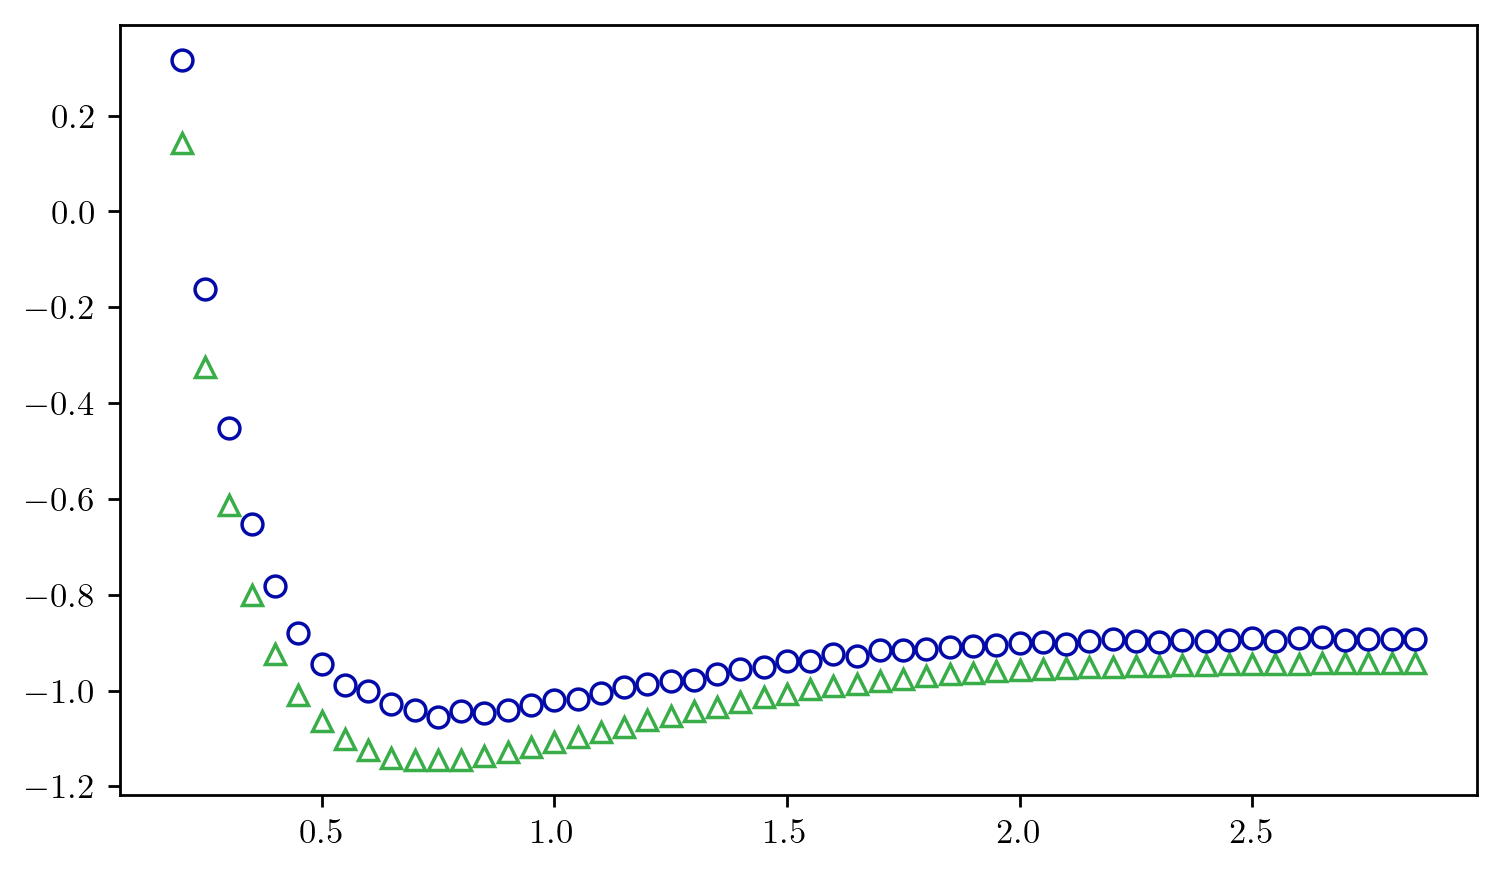

In [22]:
labelsize = 24

fig, ax1 = plt.subplots(figsize=(7, 4), dpi=250)

ax1.plot(H2_data['R'], H_opt,          marker='^', ls='', lw=2, mfc='none',
         color=colors_greg[4], label='Noiseless')
ax1.plot(H2_data['R'], H_exps_12_15,   marker='o', ls='', lw=2, mfc='none',
         color=colors_greg[2], label='Experiment')
ax1.plot(H2_data['R'], H_sim_IBM,      marker='',  ls='--', lw=2,
         color=colors_greg[1], label='Sim. IBM')
ax1.plot(H2_data['R'], H_sim_NM,       marker='',  ls='-',  lw=2,
         color=colors_greg[3], label='Sim. NM')
ax1.axvline(H2_data['R'][11], lw=1, ls='--', color='k')

ax1.set_ylabel(r'Energy $\langle H(\theta_\mathrm{opt},R) \rangle$', size=labelsize)
ax1.set_xlabel(r'$R$ (\AA)', size=labelsize)
ax1.legend(frameon=False, fontsize=20, bbox_to_anchor=(0.85, -0.25), ncol=2)
ax1.tick_params(labelsize=20)

# ── Inset: relative error ─────────────────────────────────────────────────────
ax2 = fig.add_axes([0.51, 0.45, 0.35, 0.35])
ax2.plot(H2_data['R'],
         np.abs((H_sim_IBM - H_exps_12_15) / H_exps_12_15),
         ls='--', lw=2, color=colors_greg[1])
ax2.plot(H2_data['R'],
         np.abs((H_sim_NM  - H_exps_12_15) / H_exps_12_15),
         ls='-',  lw=2, color=colors_greg[3])
ax2.axvline(H2_data['R'][11], lw=1, ls='--', color='k')
ax2.set_ylabel(r'Relative Error $\Delta_i$', size=labelsize-4)
ax2.set_xlabel(r'$R$ (\AA)', size=labelsize-4)
ax2.set_xlim(0.19, 1.2)
ax2.set_xticks([0.25, 0.5, 0.75, 1.0])
ax2.tick_params(labelsize=16)

plt.savefig('../figures/fig_09b_vqe_results.pdf', bbox_inches='tight')
plt.show()
print("Saved: ../figures/fig_09b_vqe_results.pdf")